# Plan - Bloc 2 - Feature Engineering
1.Filtrer les bâtiments non-résidentiels → df_s1  
2.Sélectionner les colonnes utiles → df_s2  
3.Créer les features métier → colonnes ajoutées à df_s2  
4.Analyser les distributions — boxplots (ratio_feats + other_feats)  
5.Analyser les outliers — zoom sur total_ty_gfa  
6.Analyser les distributions — barplots (bool_feats)  
7.Analyser les distributions — KDE (ratio_feats)  
8.Corrélation 1 — features engineerées uniquement (heatmap Spearman)  
9.Corrélation 2 — features engineerées + features brutes (heatmap Spearman)  
10.Sélectionner les features finales → df_s4  
11.Nettoyer les NaN / inf  
12.Exporter → df_s4.csv  

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import missingno as msno
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr

In [3]:
df = pd.read_csv('../data/2016_Building_Energy_Benchmarking.csv')

In [4]:
# Step 1 : Isolation du df des bâtiments à fonction residentielle

# On selectionne de nouveaux uniquement les type non residentiels et on l'instancie.abs
df['BuildingType'].value_counts()

# Les colonnes non residentiel sont :['NonResidential', 'Nonresidential COS', 'SPS-District K-12', 'Nonresidential WA', 'Campus']
df_s1 = df[df['BuildingType'].isin(['NonResidential', 'Nonresidential COS', 'SPS-District K-12', 'Nonresidential WA', 'Campus'])]

print(f"Avant {len(df)} lignes, après {len(df_s1)}")

Avant 3376 lignes, après 1668


In [5]:
# Step 2 : Préselection des colonnes du df pour le featuring
# Les colonnes à garder pour la modelisation, selon l'EDA.
feats_to_keep = [
    'BuildingType',
    'PrimaryPropertyType',
    'Neighborhood',
    'NumberofBuildings',
    'NumberofFloors',
    'PropertyGFATotal',
    'PropertyGFAParking',
    'PropertyGFABuilding(s)',
    'ListOfAllPropertyUseTypes',
    'LargestPropertyUseType',
    'LargestPropertyUseTypeGFA',
    'SecondLargestPropertyUseType',
    'SecondLargestPropertyUseTypeGFA',
    'ThirdLargestPropertyUseType',
    'ThirdLargestPropertyUseTypeGFA',
    'SiteEnergyUse(kBtu)',
]

# Les features qui vont servir uniquement à la creation de nouvelles features mais qui seront suprimer ensuite.
feats_for_eng = [
    'YearBuilt',
    'Electricity(kWh)',
    'NaturalGas(therms)',
    'SteamUse(kBtu)',
]

# Features uniquement pour la creation des features elles seront supprimer par la suite
df_s2 = df_s1[feats_to_keep + feats_for_eng]

# On regarde que le nombre de lignes correspond et que tout est là
print(df_s2.info())

<class 'pandas.DataFrame'>
Index: 1668 entries, 0 to 3375
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   BuildingType                     1668 non-null   str    
 1   PrimaryPropertyType              1668 non-null   str    
 2   Neighborhood                     1668 non-null   str    
 3   NumberofBuildings                1666 non-null   float64
 4   NumberofFloors                   1668 non-null   int64  
 5   PropertyGFATotal                 1668 non-null   int64  
 6   PropertyGFAParking               1668 non-null   int64  
 7   PropertyGFABuilding(s)           1668 non-null   int64  
 8   ListOfAllPropertyUseTypes        1666 non-null   str    
 9   LargestPropertyUseType           1662 non-null   str    
 10  LargestPropertyUseTypeGFA        1662 non-null   float64
 11  SecondLargestPropertyUseType     855 non-null    str    
 12  SecondLargestPropertyUseTypeGFA  855

Création des features : 
- building_age — âge du bâtiment = 2016 - YearBuilt
- ratio_parking — part de la surface dédiée au parking = PropertyGFAParking / PropertyGFATotal
- ratio_build — part de la surface dédiée aux bâtiments = PropertyGFABuilding(s) / PropertyGFATotal
- use_electricity — flag : utilise de l'électricité = Electricity(kWh) > 0
- use_gaz — flag : utilise du gaz = NaturalGas(therms) > 0
- use_steam — flag : utilise de la vapeur = SteamUse(kBtu) > 0
- sum_energy_use — nombre de types d'énergie = use_electricity + use_gaz + use_steam
- total_ty_gfa — surface totale des usages = LargestGFA + SecondGFA + ThirdGFA
- ratio_prime_ty_gfa — part du 1er usage = LargestGFA / total_ty_gfa
- ratio_second_ty_gfa — part du 2ème usage = SecondGFA / total_ty_gfa
- ratio_third_ty_gfa — part du 3ème usage = ThirdGFA / total_ty_gfa
- has_second_use — flag : a un 2ème usage = SecondLargestPropertyUseTypeGFA.notna()
- has_third_use — flag : a un 3ème usage = ThirdLargestPropertyUseTypeGFA.notna()
- sum_types_use — nombre total d'usages = br>has_second_use + has_third_use + 1
- floor_surface — surface par étage = br>PropertyGFATotal / NumberofFloors
- building_surface — surface par bâtiment = PropertyGFATotal / NumberofBuildings

In [6]:
df_s2.columns.tolist()

['BuildingType',
 'PrimaryPropertyType',
 'Neighborhood',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'SiteEnergyUse(kBtu)',
 'YearBuilt',
 'Electricity(kWh)',
 'NaturalGas(therms)',
 'SteamUse(kBtu)']

In [7]:
# Step 3: Featuring
# feature âge des bâtiments
df_s2['building_age'] = 2016 - df_s2['YearBuilt']

# feature du groupe des surfaces des structures
df_s2['ratio_parking'] =  df_s2['PropertyGFAParking'] / df_s2['PropertyGFATotal']
df_s2['ratio_build'] =  df_s2['PropertyGFABuilding(s)'] / df_s2['PropertyGFATotal']

# features pour le type d'energie utilisée
df_s2['use_electricity'] = (df_s2['Electricity(kWh)'] > 0).astype(int)
df_s2['use_gaz'] = (df_s2['NaturalGas(therms)'] > 0).astype(int)
df_s2['use_steam'] = (df_s2['SteamUse(kBtu)'] > 0).astype(int)
df_s2['sum_energy_use'] = df_s2['use_electricity'] + df_s2['use_gaz'] + df_s2['use_steam']

# feature pour les ratios de surface des usages
df_s2['total_ty_gfa'] = (df_s2['LargestPropertyUseTypeGFA'].fillna(0) + df_s2['SecondLargestPropertyUseTypeGFA'].fillna(0) + df_s2['ThirdLargestPropertyUseTypeGFA'].fillna(0))
df_s2['ratio_prime_ty_gfa'] =  df_s2['LargestPropertyUseTypeGFA'].fillna(0) / df_s2['total_ty_gfa']
df_s2['ratio_second_ty_gfa'] =  df_s2['SecondLargestPropertyUseTypeGFA'].fillna(0) / df_s2['total_ty_gfa']
df_s2['ratio_third_ty_gfa'] =  df_s2['ThirdLargestPropertyUseTypeGFA'].fillna(0) / df_s2['total_ty_gfa']

# feature pour quantifier les usages
df_s2['has_second_use'] = df_s2['SecondLargestPropertyUseTypeGFA'].notna().astype(int)
df_s2['has_third_use'] = df_s2['ThirdLargestPropertyUseTypeGFA'].notna().astype(int)
df_s2['sum_types_use'] = df_s2['has_second_use'] + df_s2['has_third_use'] + 1 # +1 car toujours un usage principal

# surface par nombre d'etages 
df_s2['floor_surface'] = df_s2['PropertyGFATotal'] / df_s2['NumberofFloors']

# surface par bâtiments
df_s2['building_surface'] = df_s2['PropertyGFATotal'] / df_s2['NumberofBuildings']

# check
display(df_s2.head())


,BuildingType,PrimaryPropertyType,Neighborhood,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,...,sum_energy_use,total_ty_gfa,ratio_prime_ty_gfa,ratio_second_ty_gfa,ratio_third_ty_gfa,has_second_use,has_third_use,sum_types_use,floor_surface,building_surface
0,NonResidential,Hotel,DOWNTOWN,1.0,12,88434,0,88434,Hotel,Hotel,...,3,88434.0,1.000000,0.000000,0.000000,0,0,1,7369.500000,88434.0
1,NonResidential,Hotel,DOWNTOWN,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,...,2,103566.0,0.809918,0.145453,0.044629,1,1,3,9415.090909,103566.0
2,NonResidential,Hotel,DOWNTOWN,1.0,41,956110,196718,759392,Hotel,Hotel,...,3,756493.0,1.000000,0.000000,0.000000,0,0,1,23319.756098,956110.0
3,NonResidential,Hotel,DOWNTOWN,1.0,10,61320,0,61320,Hotel,Hotel,...,3,61320.0,1.000000,0.000000,0.000000,0,0,1,6132.000000,61320.0
4,NonResidential,Hotel,DOWNTOWN,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,...,2,191454.0,0.644776,0.355224,0.000000,1,1,3,9754.444444,175580.0


In [8]:
# Step 4: Analyse des nouvelles features
# barplots
bool_feats = ['use_electricity', 'use_gaz', 'use_steam', 
              'has_second_use', 'has_third_use']

# boxplots
ratio_feats = ['ratio_parking', 'ratio_build', 'ratio_prime_ty_gfa', 
               'ratio_second_ty_gfa', 'ratio_third_ty_gfa']

# histogramme
other_feats = ['building_age', 'total_ty_gfa', 'sum_energy_use', 'sum_types_use', 'floor_surface', 'building_surface']

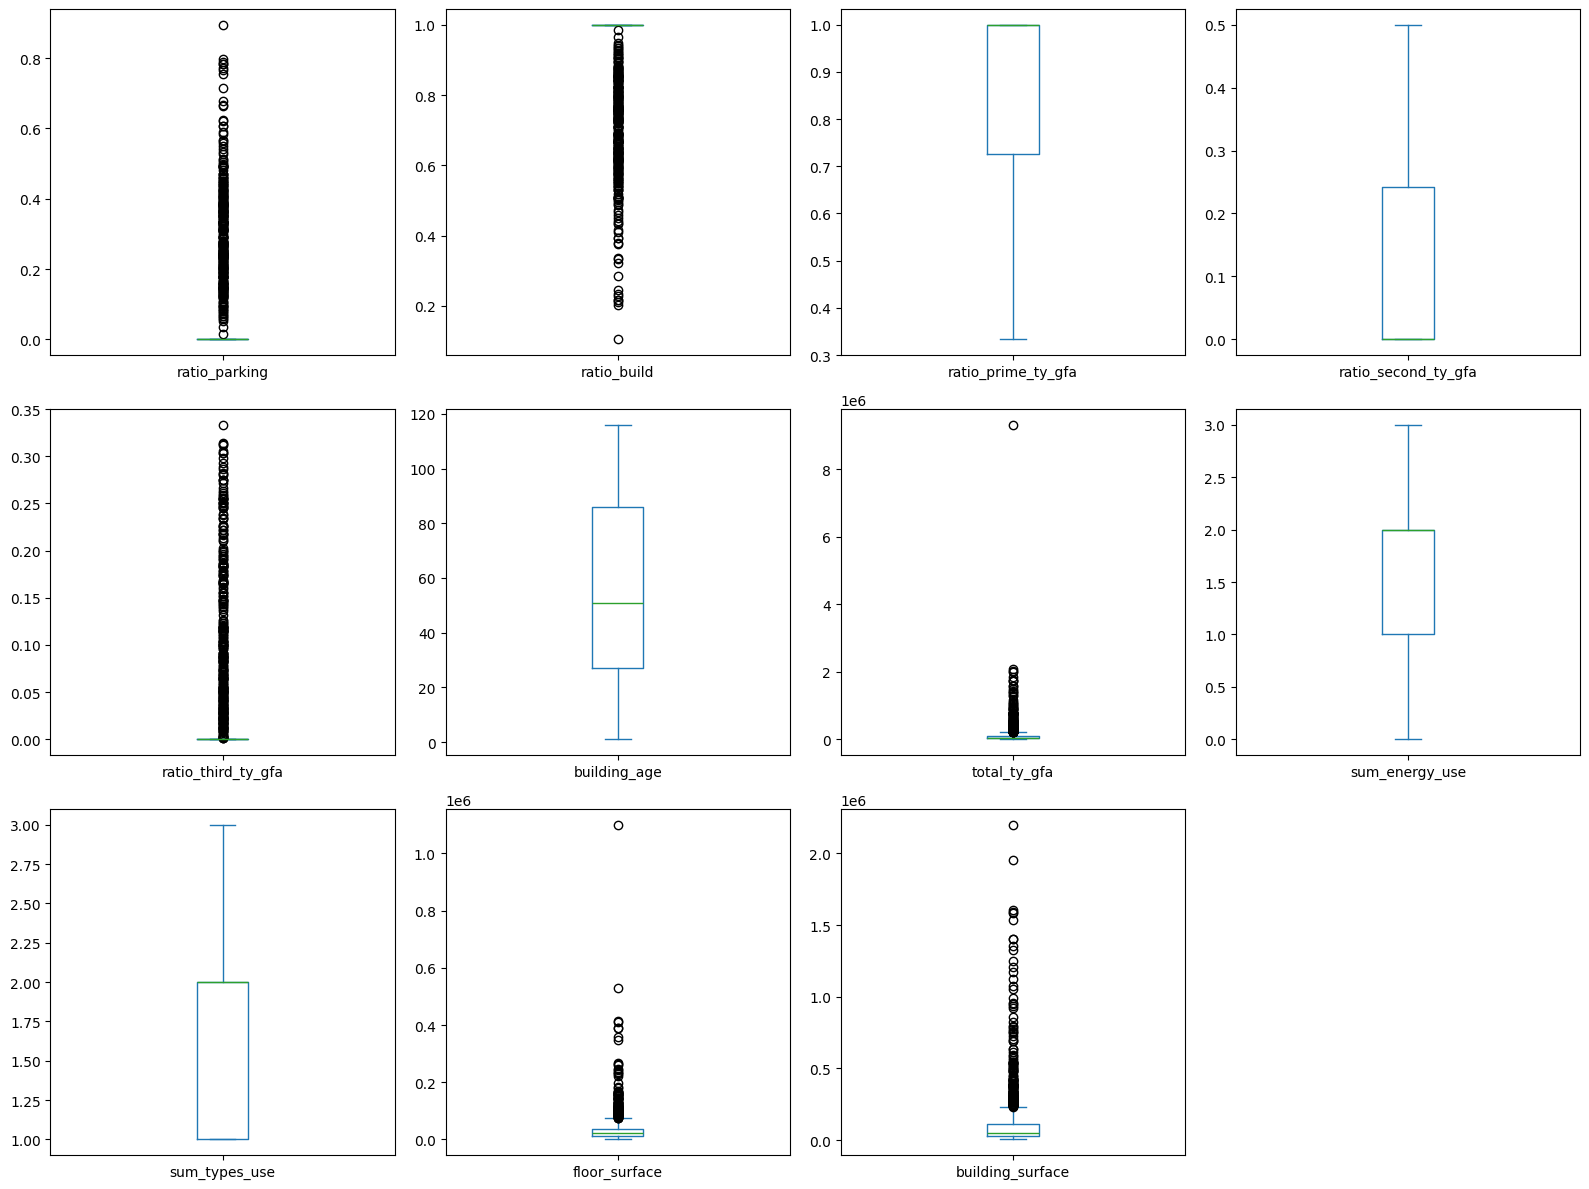

In [9]:
# boxplots
df_s2[ratio_feats + other_feats].plot(kind = 'box', subplots = True, layout = (3, 4), figsize = (16, 12))
plt.tight_layout()
plt.show()

In [10]:
# Analyse des outliers
df_s2['total_ty_gfa'].describe()
df_s2[df_s2['total_ty_gfa'] == df_s2['total_ty_gfa'].max()]

,BuildingType,PrimaryPropertyType,Neighborhood,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,...,sum_energy_use,total_ty_gfa,ratio_prime_ty_gfa,ratio_second_ty_gfa,ratio_third_ty_gfa,has_second_use,has_third_use,sum_types_use,floor_surface,building_surface
3274,Campus,University,NORTHEAST,111.0,0,9320156,0,9320156,College/University,College/University,...,2,9320156.0,1.0,0.0,0.0,0,0,1,inf,83965.369369


Pour la colonne la variable total_ty_gfa on observe un otlier extreme mais qui est juste il faut donc le garder car c'est une grande université.  
Pour les colonnes ratio, l'IQR est vide donc ce qui existe est placé comme outlier, d'ou ces données mais elle reste juste.

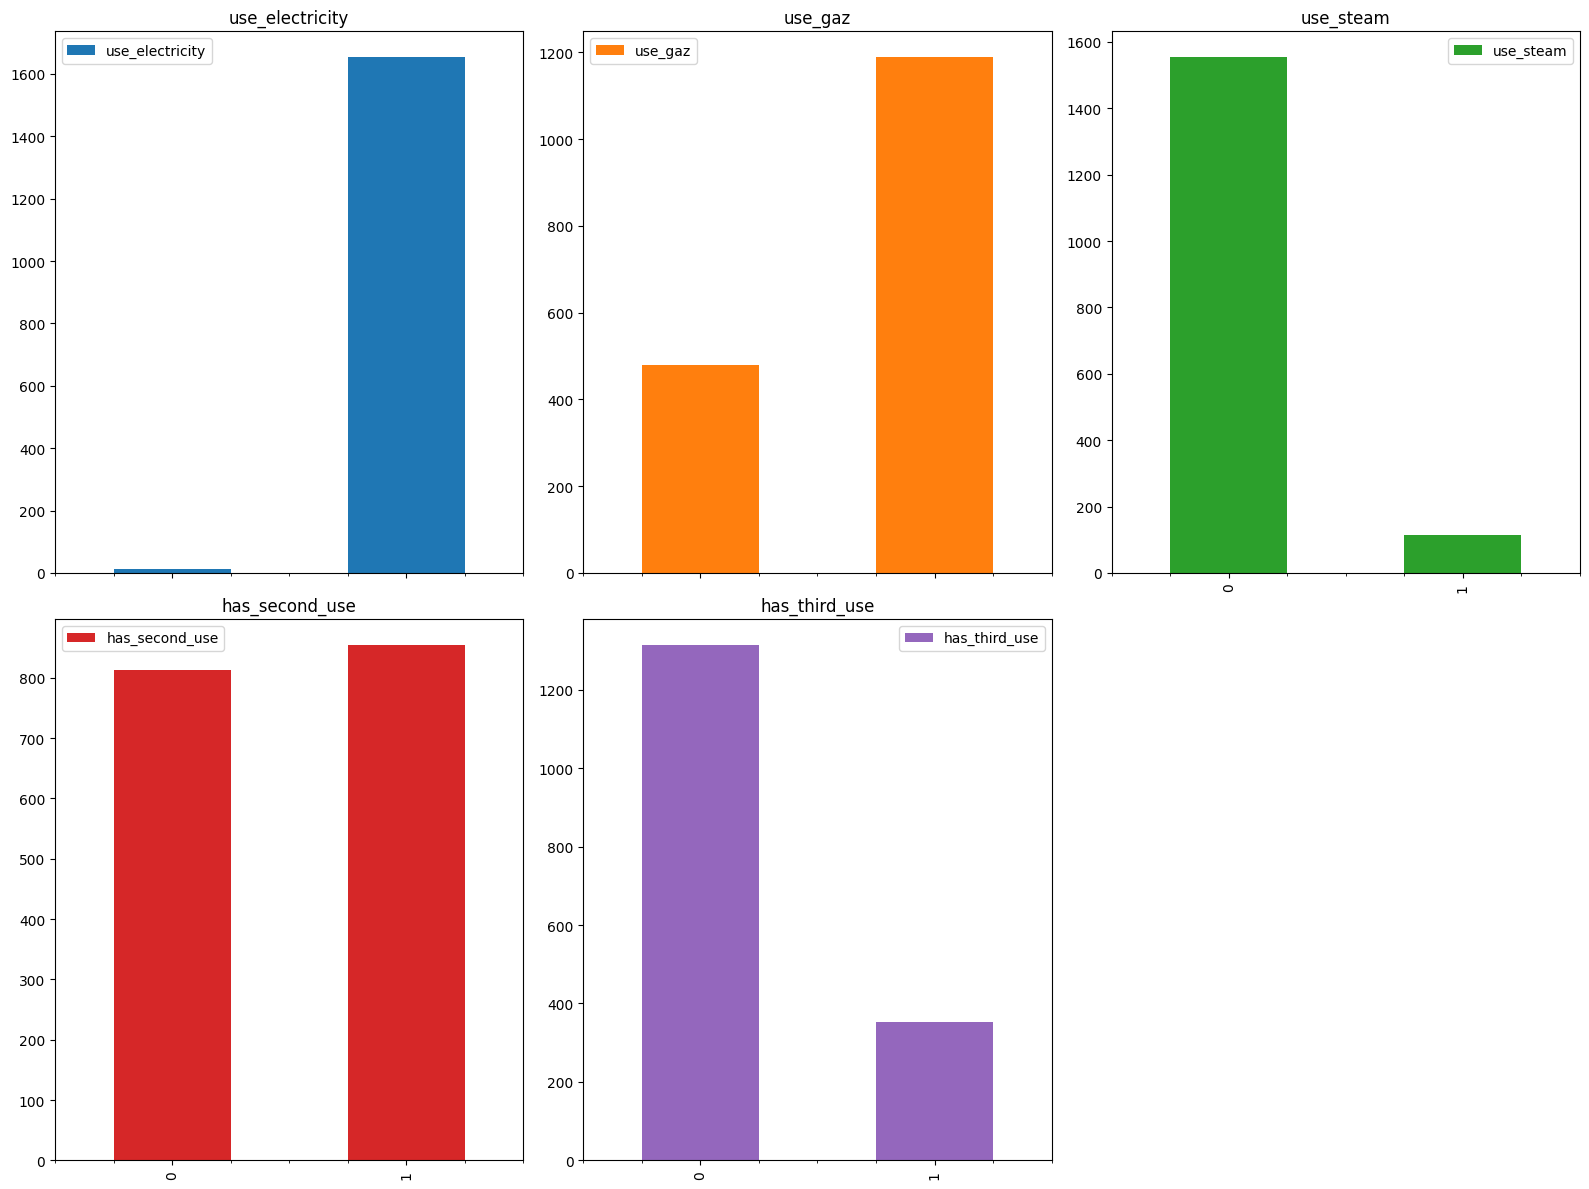

In [11]:
# barplots
df_s2[bool_feats].apply(pd.Series.value_counts).plot(kind = 'bar', subplots = True,   layout = (2,3), figsize = (16,12) )
plt.tight_layout()
plt.show()

Les barplots sont très coherents.  
La feature sur l'usage est peu discriminante, il n'est probablement pas utile de la garder pour la modélisation.   
Toutefois , cela reste à confirmer avec la heatmap de correlation.

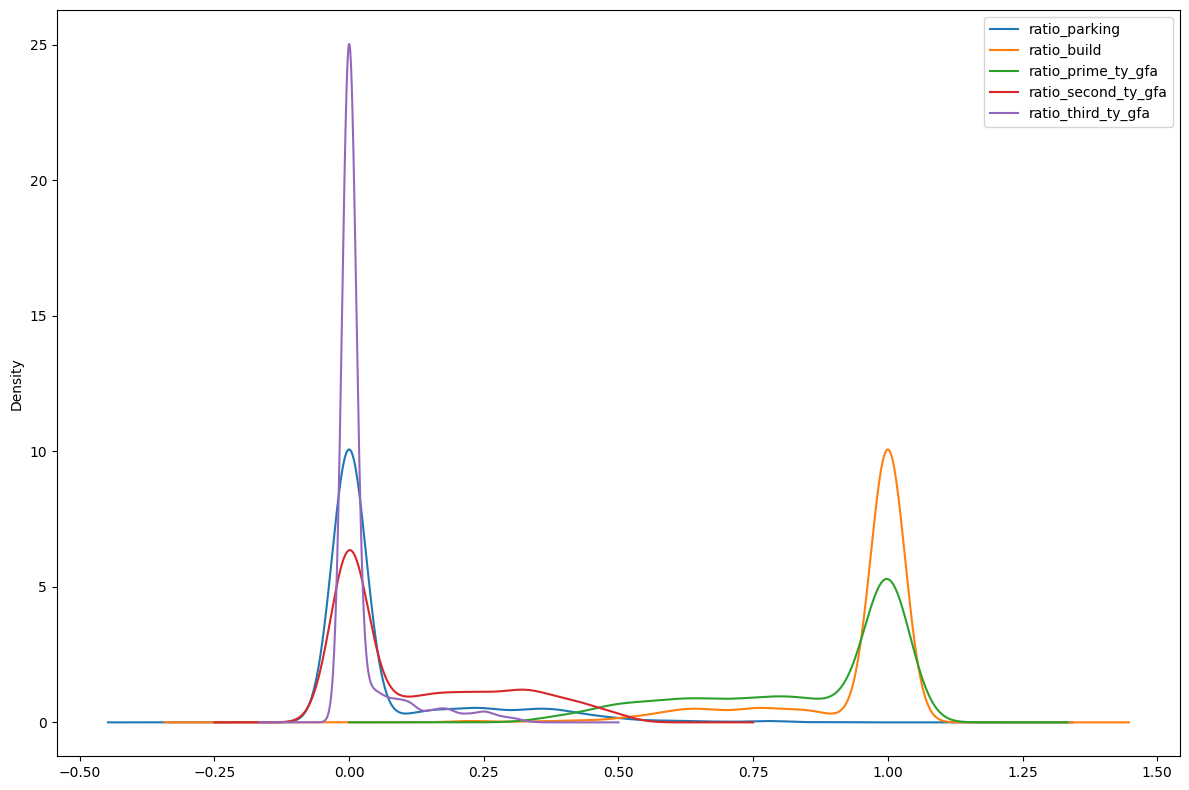

In [12]:
#Histogramme
df_s2[ratio_feats].plot(kind = 'kde', figsize = (12, 8))
plt.legend()
plt.tight_layout()
plt.show()

- La majorité des bâtiments sont mono ou double usage mais pas triple usage; courbe violette (triple)élevée à 0. 
- Peu ont un troisième usage.
- La plupart n'ont pas ou très peu de parking, mais la symmétrie est troublante, cela indique qu'il ne s'agit pas vraiement de parking au sens propre mais plutôt de l'espace non - batie, car il s'oppose mecaniquement (symetriquement par le ratio partie/globale) au building...par consequent cette features c'est pas nécessaire.
- **Les ratios sont complémentaires par construction, cela se voit par l'effet miroir entre les courbes, il y a donc de la redondance dans les features.**

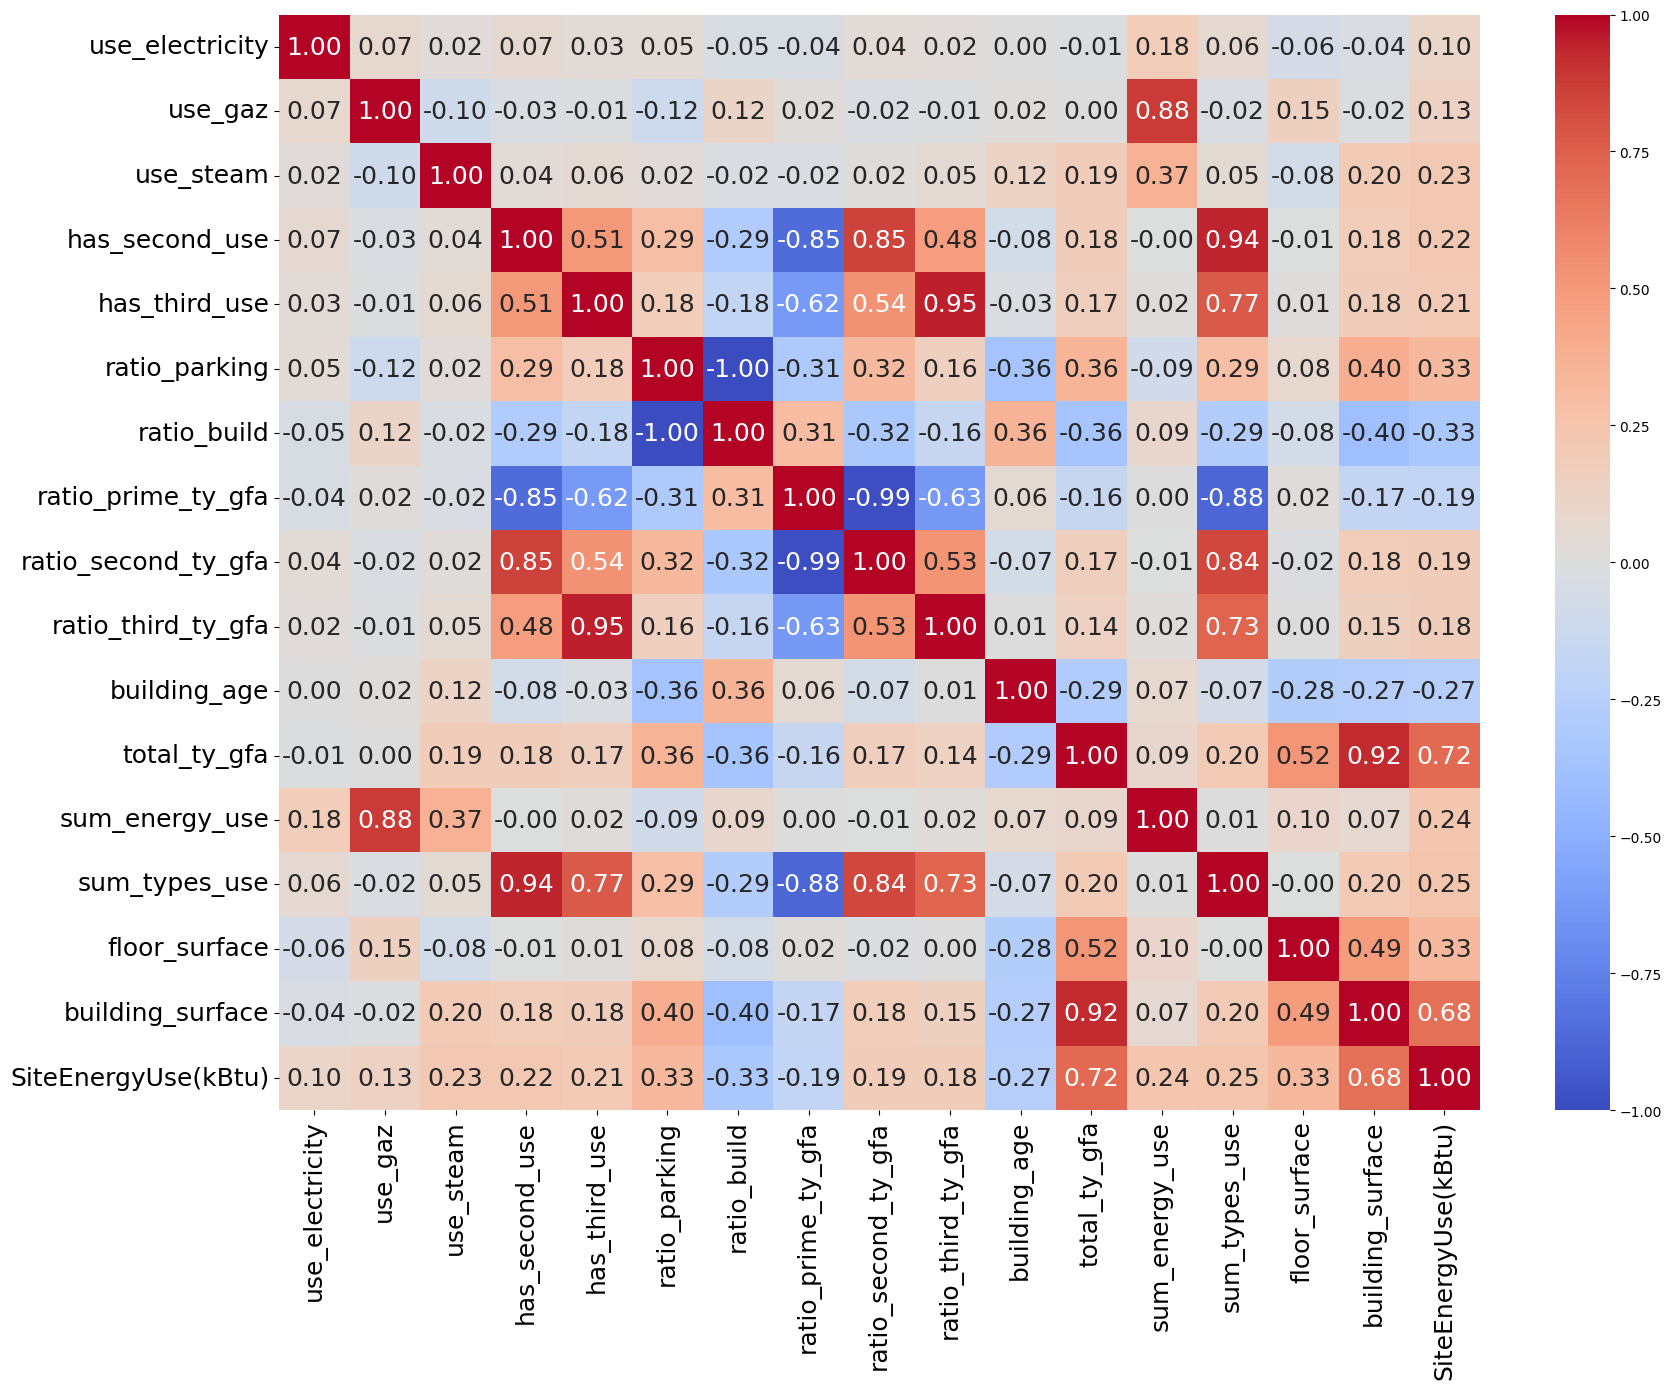

In [ ]:
# corrélation 1 (sans features brute)

# heatmap de correlation des features - les donnée surs lesquelles n veut voir la corrélation
feat_corr = df_s2[bool_feats + ratio_feats + other_feats + ['SiteEnergyUse(kBtu)']].select_dtypes(include = 'number').columns

# instance de la fonction de correlation 
corr_matrix = df_s2[feat_corr].corr(method = 'spearman')

# configuration de l'affichage de la heatmap
plt.figure(figsize = (18, 14))
sns.heatmap(
    corr_matrix,
    annot = True, 
    fmt = '.2f', 
    cmap = 'coolwarm', 
    annot_kws = {"size": 18},
    )
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.tight_layout()
plt.show()

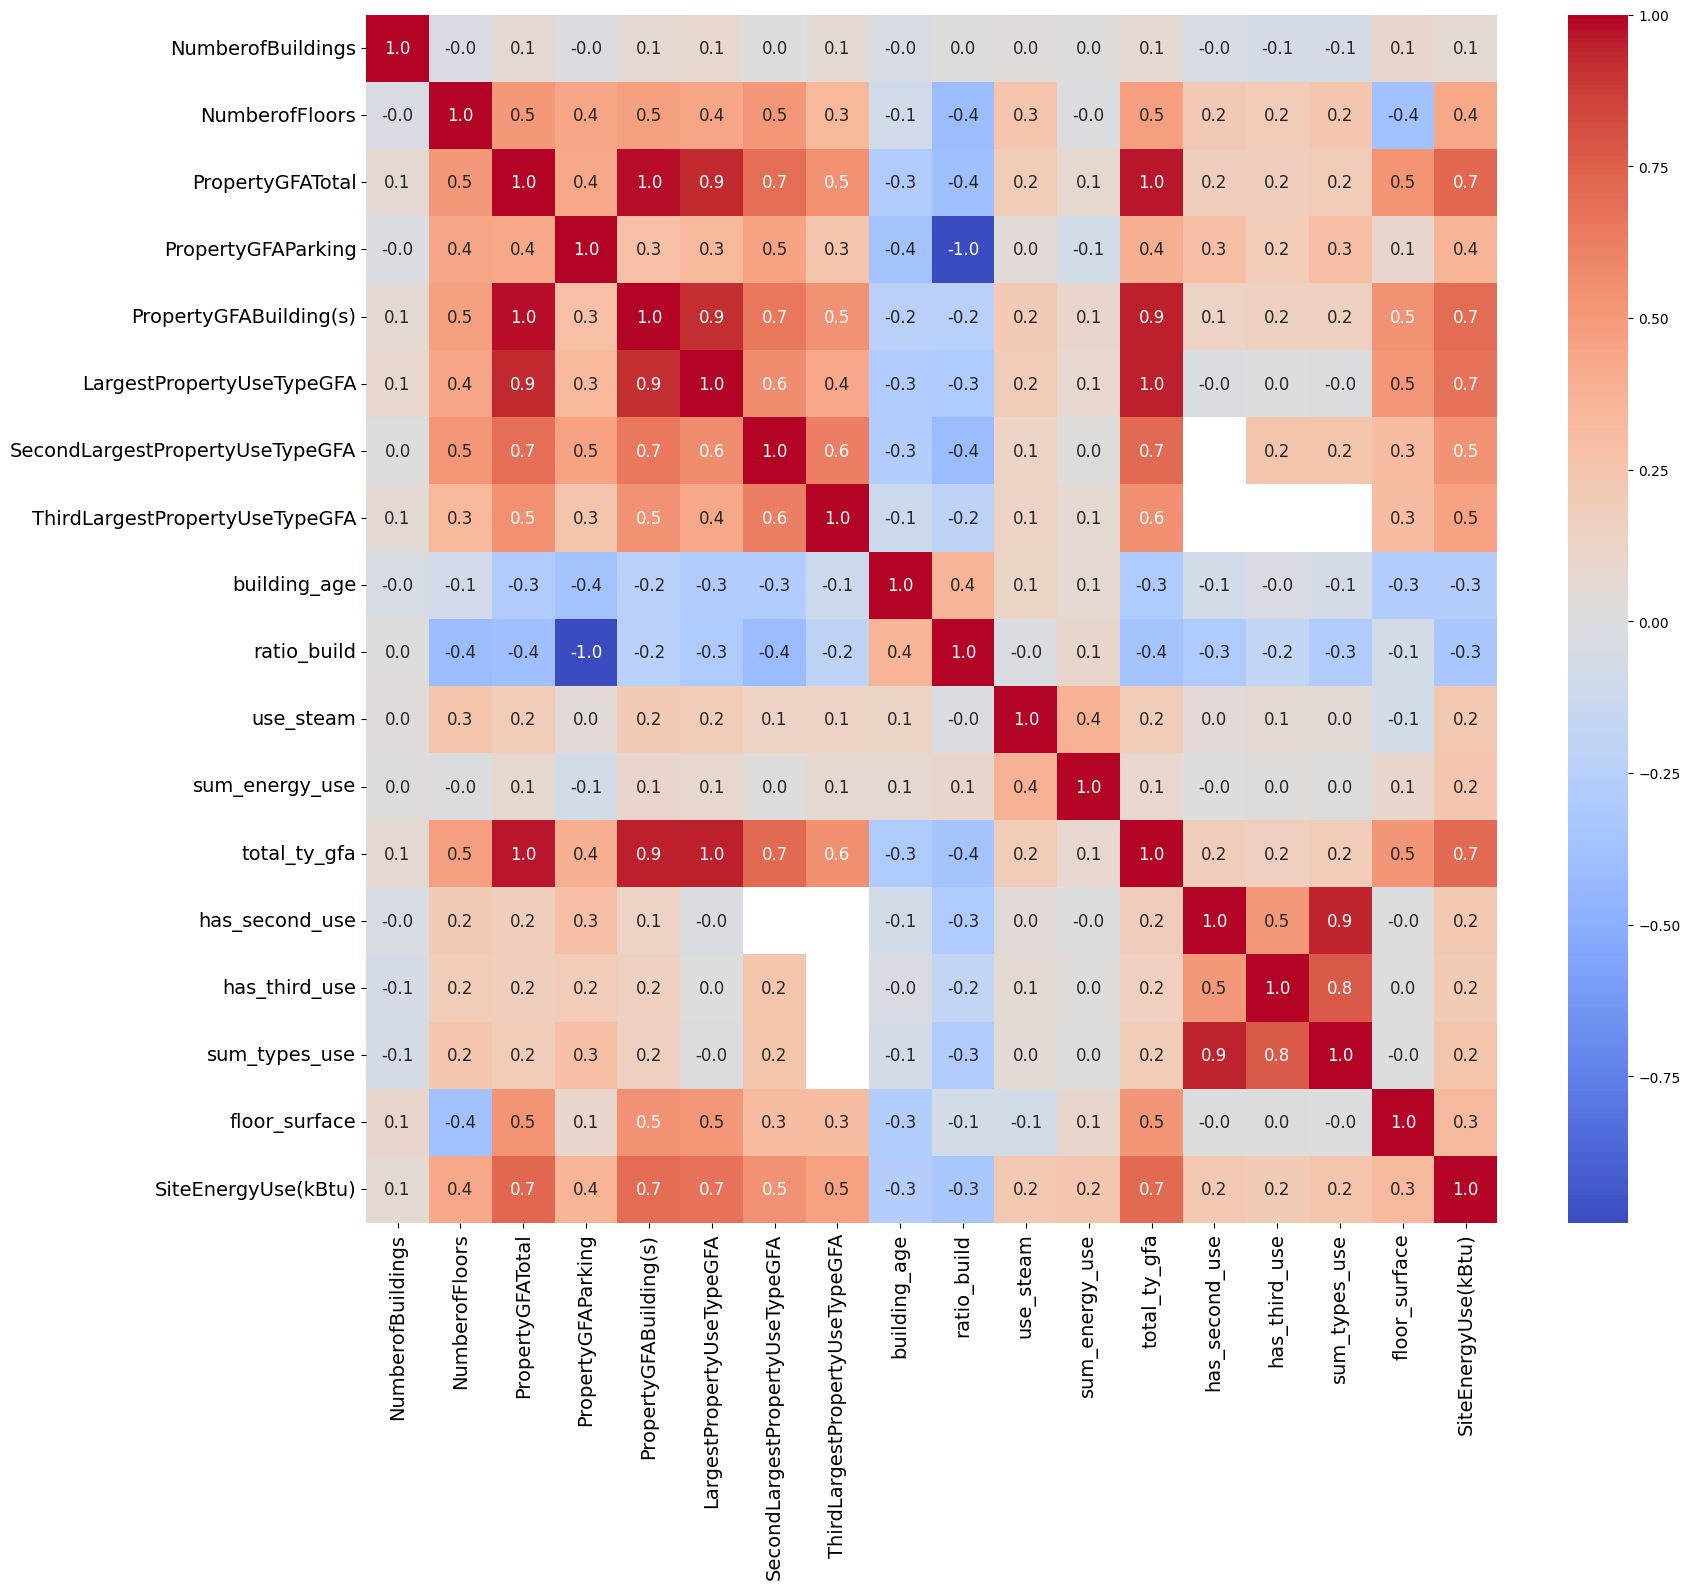

In [14]:
# corrélation 2 (avec features brute)

# correlation toujours non categorielle
df_s2_test = df_s2[[
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',# X
 'PropertyGFAParking',# X
 'PropertyGFABuilding(s)',# X
 'LargestPropertyUseTypeGFA',# X
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseTypeGFA',
 'building_age',
 'ratio_build',
 'use_steam',
 'sum_energy_use',
 'total_ty_gfa',
 'has_second_use',# X
 'has_third_use',
 'sum_types_use',
 'floor_surface',
'SiteEnergyUse(kBtu)']].select_dtypes(include = 'number').columns

# corrélation
corr_matrix_test = df_s2[df_s2_test].corr(method = 'spearman')

# pareil, affichage de la corrélation sur une heatmap
plt.figure(figsize = (18, 16))
sns.heatmap(
    corr_matrix_test, 
    annot = True, 
    fmt = '.1f',
    cmap = 'coolwarm',
    annot_kws = {"size": 12}
)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.tight_layout()
plt.show()


À partir de cette heatmap nous allons décider des features à conserver et celle à supprimer.  
À noter, il s'agit d'une heatmap 'spearman' et non 'pearson'.   
Spearman, pourquoi ? Présence de outliers et de binaire donc plus pertinent car moins proportionnel, pearson etant recommendé pour la proportionnalitée.

In [15]:
# df final des features

# colonnes à conserver pour la modélisation > df_s4 > step 4
df_s4 = df_s2[ [
    'building_age',
    'BuildingType',
    'floor_surface',
    'has_third_use',
    'Neighborhood',
    'NumberofBuildings',
    'NumberofFloors',
    'PrimaryPropertyType',
    'ratio_build',
    'SecondLargestPropertyUseTypeGFA',
    'SiteEnergyUse(kBtu)',
    'sum_energy_use',
    'sum_types_use',
    'ThirdLargestPropertyUseTypeGFA',
    'total_ty_gfa',
    'use_steam',
]]

# stats du df
df_s4.describe()

/home/mohamed/Formation/Data Engineer/Projet 06 Anticipez les besoins de consomation de batiments/p6-ml-seattle-co2-energy-prediction/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,building_age,floor_surface,has_third_use,NumberofBuildings,NumberofFloors,ratio_build,SecondLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),sum_energy_use,sum_types_use,ThirdLargestPropertyUseTypeGFA,total_ty_gfa,use_steam
count,1668.000000,1.668000e+03,1668.000000,1666.000000,1668.000000,1668.000000,855.000000,1.666000e+03,1668.000000,1668.000000,353.00000,1.668000e+03,1668.000000
mean,54.086331,inf,0.211631,1.168667,4.121103,0.938886,36804.160581,8.437933e+06,1.772782,1.724221,14923.13994,1.204331e+05,0.068345
std,32.741755,NaN,0.408587,2.931409,6.563407,0.140075,69845.261024,3.024380e+07,0.511936,0.789532,36790.55656,3.057626e+05,0.252413
min,1.000000,2.216970e+02,0.000000,0.000000,0.000000,0.104977,0.000000,0.000000e+00,0.000000,1.000000,0.00000,0.000000e+00,0.000000
25%,27.000000,1.329799e+04,0.000000,1.000000,1.000000,1.000000,5350.000000,1.229291e+06,1.000000,1.000000,2663.00000,2.937450e+04,0.000000
50%,51.000000,2.293362e+04,0.000000,1.000000,2.000000,1.000000,12000.000000,2.554947e+06,2.000000,2.000000,5931.00000,4.996300e+04,0.000000
75%,86.000000,3.821275e+04,0.000000,1.000000,4.000000,1.000000,31881.000000,6.913348e+06,2.000000,2.000000,12941.00000,1.030600e+05,0.000000
max,116.000000,inf,1.000000,111.000000,99.000000,1.000000,686750.000000,8.739237e+08,3.000000,3.000000,459748.00000,9.320156e+06,1.000000


Présence de inf, -inf, et de nan. On nettoie simple pour avoir une bonne base pour le bloc 3, la préparation des données.

<Axes: >

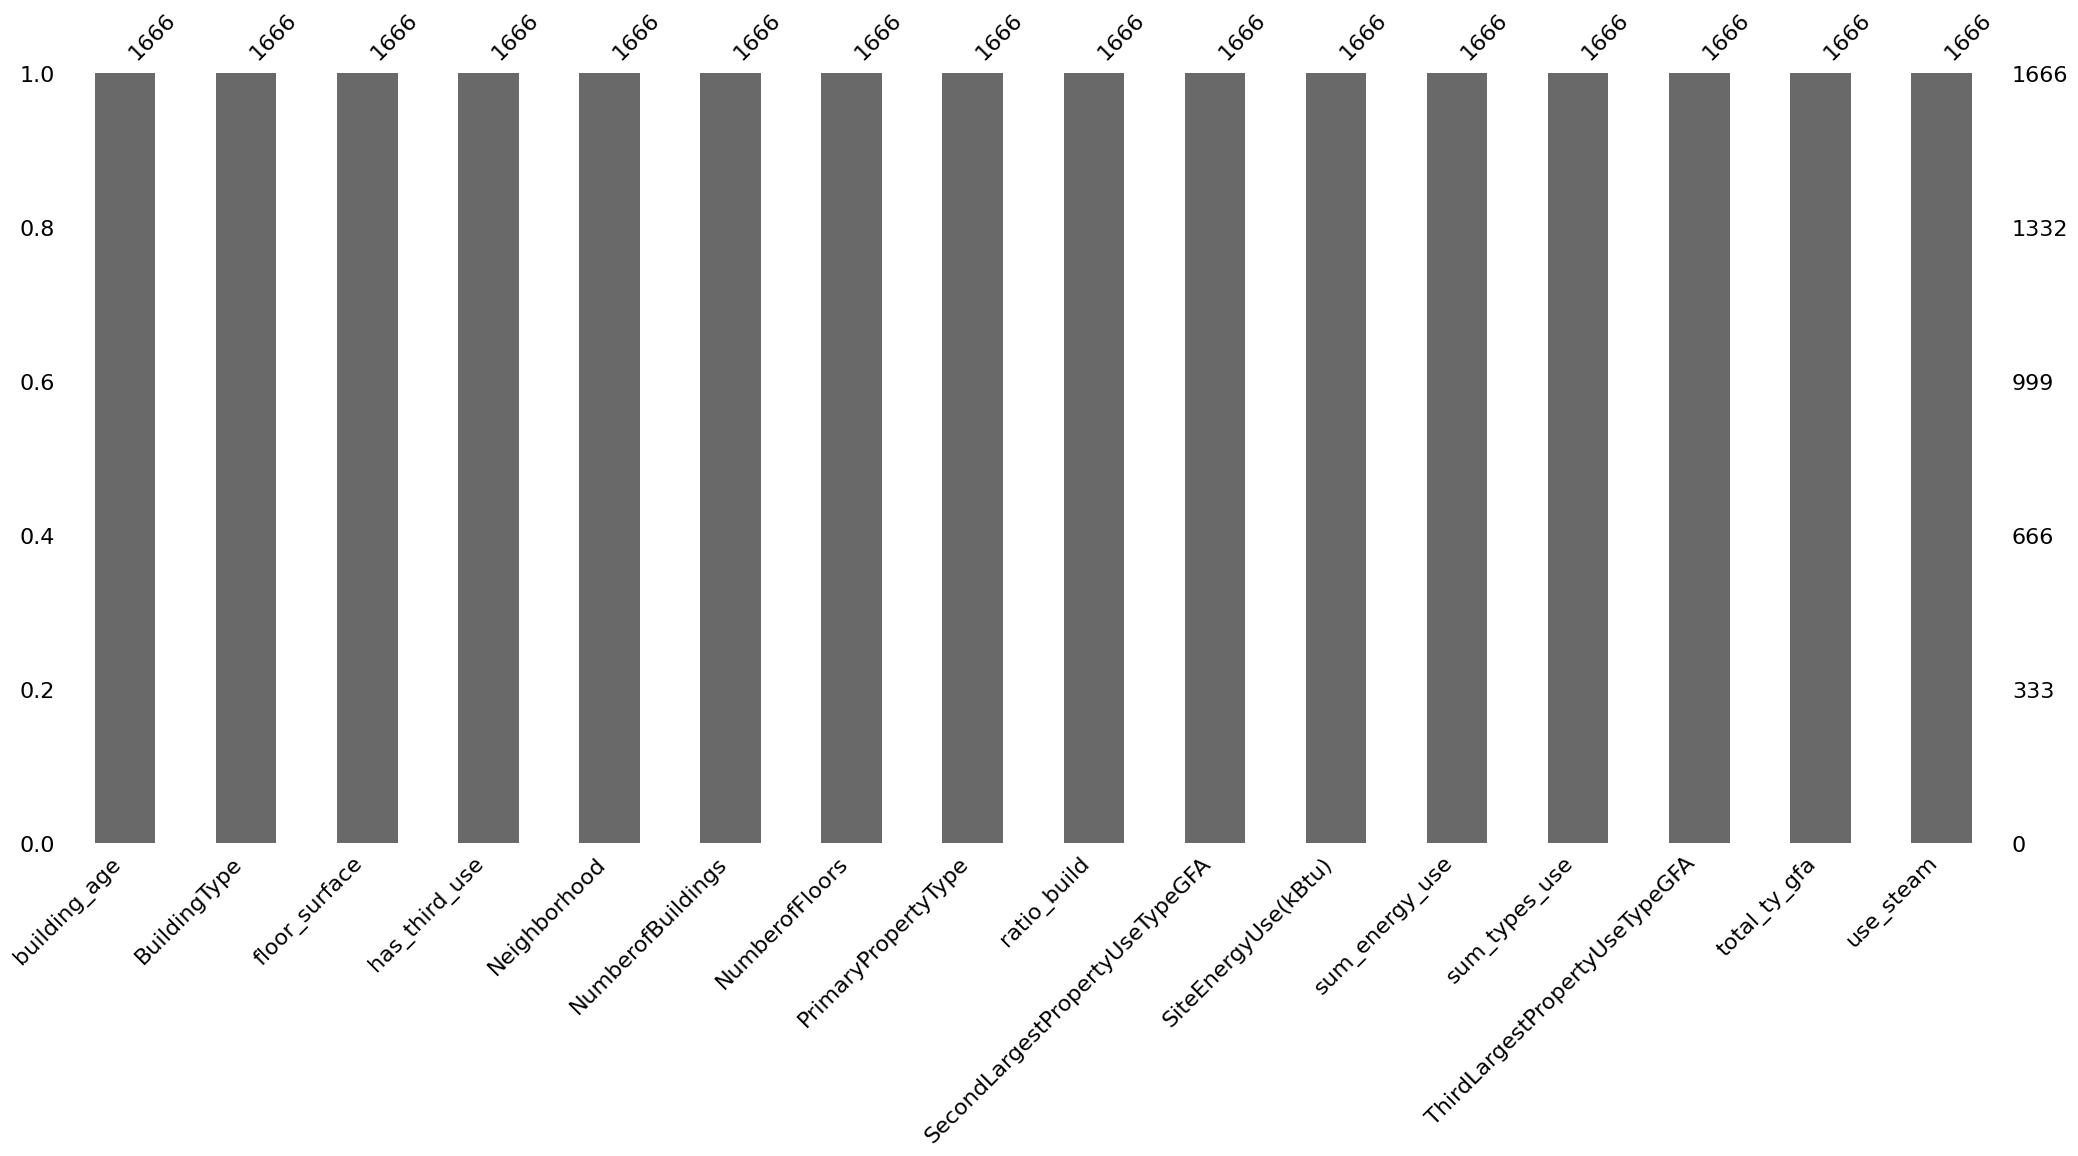

In [16]:
# supprime les entrées avec une target manquantes
df_s4 = df_s4.dropna(subset = ['SiteEnergyUse(kBtu)'])

# on convertit les inf en nan
df_s4 = df_s4.replace([np.inf, -np.inf],np.nan)

# on remplace tout les nan par veleurs numeriques = 0
df_s4 = df_s4.fillna(0)

# visuel du résultat
msno.bar(df_s4)

In [18]:
# export en csv afin de le récupérer pour le notebook du bloc 3
df_s4.to_csv('../data/df_s4.csv', index=False)

df_s4.info()

<class 'pandas.DataFrame'>
Index: 1666 entries, 0 to 3375
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   building_age                     1666 non-null   int64  
 1   BuildingType                     1666 non-null   str    
 2   floor_surface                    1666 non-null   float64
 3   has_third_use                    1666 non-null   int64  
 4   Neighborhood                     1666 non-null   str    
 5   NumberofBuildings                1666 non-null   float64
 6   NumberofFloors                   1666 non-null   int64  
 7   PrimaryPropertyType              1666 non-null   str    
 8   ratio_build                      1666 non-null   float64
 9   SecondLargestPropertyUseTypeGFA  1666 non-null   float64
 10  SiteEnergyUse(kBtu)              1666 non-null   float64
 11  sum_energy_use                   1666 non-null   int64  
 12  sum_types_use                    166

Fin du notebook de features engineering avec le dataframe qui sera exploité pour la préparation des données et la modélisation.